In [44]:
import os
import json
import pandas as pd
import humanize
import re
import numpy as np
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
pd.set_option('display.max_columns', None)

In [45]:
def split_vec3(s):
  vec3 = [float(x) for x in s.strip('()[]').split(',')]
  return vec3


def matrix_str_to_euler(rotation_str):
  """
  Парсит строку с матрицей поворота и возвращает углы Эйлера (в градусах).
  Формат строки: "[X: (x, y, z), Y: (x, y, z), Z: (x, y, z)]"
  
  Возвращает:
      tuple: (угол_X, угол_Y, угол_Z) в градусах
  """
  # Извлекаем числа из строки с помощью регулярного выражения
  numbers = re.findall(r"[-+]?\d*\.\d+|\d+", rotation_str)
  if len(numbers) != 9:
      raise ValueError("Некорректный формат матрицы поворота")
  
  # Преобразуем строки в числа float
  matrix = np.array([float(x) for x in numbers]).reshape(3, 3)
  
  # Конвертируем матрицу поворота в углы Эйлера (XYZ порядок)
  rot = Rotation.from_matrix(matrix)
  euler_angles = rot.as_euler('xyz', degrees=True)
  
  return tuple(euler_angles)

In [46]:
data = []
folder = 'proj_v2'
for fn in os.listdir(folder):
  if fn.endswith('.json'):
    with open(f"{folder}/{fn}", "r") as f:
      raw = json.load(f)
      data.append(raw)

In [47]:
df_raw = pd.json_normalize(data)
# df_raw.dropna(axis=0, how='all', inplace=True)
df_raw[['ang_vel.x', 'ang_vel.y', 'ang_vel.z']] = df_raw['angular_velocity_local'].apply(lambda x: split_vec3(x)).to_list()
df_raw[['position.x', 'position.y', 'position.z']] = df_raw['position'].apply(lambda x: split_vec3(x)).to_list()
df_raw[['velocity.x', 'velocity.y', 'velocity.z']] = df_raw['velocity'].apply(lambda x: split_vec3(x)).to_list()
df_raw['velocity_length'] = (df_raw['velocity.x']**2 + df_raw['velocity.y']**2 + df_raw['velocity.z']**2)**0.5
df_raw['kinetic_energy'] = 0.5 * (df_raw['mass'] / 1000) * df_raw['velocity_length']**2
df_raw[['euler.x', 'euler.y', 'euler.z']] = df_raw['rotation'].apply(lambda x: matrix_str_to_euler(x)).to_list()
df_raw.drop(['angular_velocity_local', 'position', 'velocity'], axis=1, inplace=True)
df_raw.columns

Index(['ammo', 'ammo.name', 'angular_velocity', 'caliber', 'core_caliber',
       'core_hardness', 'core_mass', 'cross_section', 'drag_coef',
       'flight_time', 'fragmentation_chance', 'fragmentation_count',
       'fragments_max', 'fragments_min', 'impact_count', 'kind', 'length',
       'length_diameter_ratio', 'magnus_effect_factor', 'mass',
       'penetration_count', 'ricochet_count', 'ricochet_max_angle',
       'ricochet_min_angle', 'rotation', 'spin_decay_rate', 'state', 'ttl',
       'uid', 'weapon', 'weapon.name', 'ang_vel.x', 'ang_vel.y', 'ang_vel.z',
       'position.x', 'position.y', 'position.z', 'velocity.x', 'velocity.y',
       'velocity.z', 'velocity_length', 'kinetic_energy', 'euler.x', 'euler.y',
       'euler.z'],
      dtype='object')

In [48]:
cols = ['weapon.name', 'ammo.name', 'uid', 'flight_time',
        'position.x', 'position.y', 'position.z',
        'velocity.x', 'velocity.y', 'velocity.z', 'velocity_length',
        'ang_vel.x', 'ang_vel.y', 'ang_vel.z',
        'euler.x', 'euler.y', 'euler.z',
        'kinetic_energy'
      ]
repl = {
  'SCAR_L_CQC': 'SCAR-L CQC',
  'FN_EVOLYS': 'FN EVOLYS',
  'Glock17_HST': 'Glock 17',
  '9x19_HST_PlusP': '9x19 HST +P',
  '5.56x45_M855': '5.56x45 M855',
  '7.62x51_SLAP_T': '7.62x51 SLAP-T'
}
df = df_raw[cols].sort_values('flight_time').reset_index(drop=True)
df['weapon'] = df['weapon.name'].replace(repl, regex=False) + \
  ' (' + \
  df['ammo.name'].replace(repl, regex=False) + \
  ')'
df.drop(['weapon.name', 'ammo.name'], axis=1, inplace=True)
df

,uid,flight_time,position.x,position.y,position.z,velocity.x,velocity.y,velocity.z,velocity_length,ang_vel.x,ang_vel.y,ang_vel.z,euler.x,euler.y,euler.z,kinetic_energy,weapon
0,proj_zTFDbjDf,0.016667,0.000001,1.289264,-17.283760,0.000065,7.635225,-989.7986,989.828048,0.0,0.0,-20591.340,-0.451317,-0.000011,-31.378282,3429.158478,FN EVOLYS (7.62x51 SLAP-T)
1,proj_yEHV8gk8,0.016667,0.000001,1.278337,-15.894330,0.000060,6.979640,-906.4332,906.460072,0.0,0.0,-32530.300,-0.451316,-0.000008,46.186279,1684.423216,SCAR-L CQC (5.56x45 M855)
2,proj_Srft8fhc,0.016667,0.000000,1.208696,-7.055554,0.000025,2.801138,-376.1064,376.116831,0.0,0.0,-9545.825,-0.451317,-0.000004,-26.504361,530.489514,Glock 17 (9x19 HST +P)
3,proj_yEHV8gk8,0.033333,0.000002,1.390061,-30.751030,0.000059,6.703455,-891.4015,891.426705,0.0,0.0,-32515.120,-0.451318,0.000008,93.393719,1629.015220,SCAR-L CQC (5.56x45 M855)
4,proj_Srft8fhc,0.033333,0.000001,1.252217,-13.260560,0.000024,2.611299,-372.3004,372.309558,0.0,0.0,-9541.211,-0.451301,0.000004,-52.707106,519.804025,Glock 17 (9x19 HST +P)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538,proj_Srft8fhc,3.000000,0.000042,-25.776580,-633.435400,0.000008,-18.275110,-126.6451,127.956872,0.0,0.0,-8754.485,-0.451322,0.000015,71.690786,61.398604,Glock 17 (9x19 HST +P)
539,proj_zTFDbjDf,3.000000,0.000110,-17.654650,-1668.857000,0.000022,-16.669020,-334.6997,335.114526,0.0,0.0,-18997.330,-0.451321,-0.000011,117.528345,393.056109,FN EVOLYS (7.62x51 SLAP-T)
540,proj_yEHV8gk8,3.016667,0.000082,-18.731260,-1241.219000,0.000014,-16.165890,-213.3393,213.950912,0.0,0.0,-29908.910,-0.451300,-0.000002,93.923370,93.838735,SCAR-L CQC (5.56x45 M855)
541,proj_zTFDbjDf,3.016667,0.000110,-17.934070,-1674.413000,0.000022,-16.765460,-333.3735,333.794804,0.0,0.0,-18988.780,-0.451304,0.000003,-157.256309,389.966399,FN EVOLYS (7.62x51 SLAP-T)


In [49]:
for uid in df['uid'].unique():
  q = f"uid == {uid}"
  print(q)

uid == proj_zTFDbjDf
uid == proj_yEHV8gk8
uid == proj_Srft8fhc


<Axes: xlabel='flight_time', ylabel='kinetic_energy'>

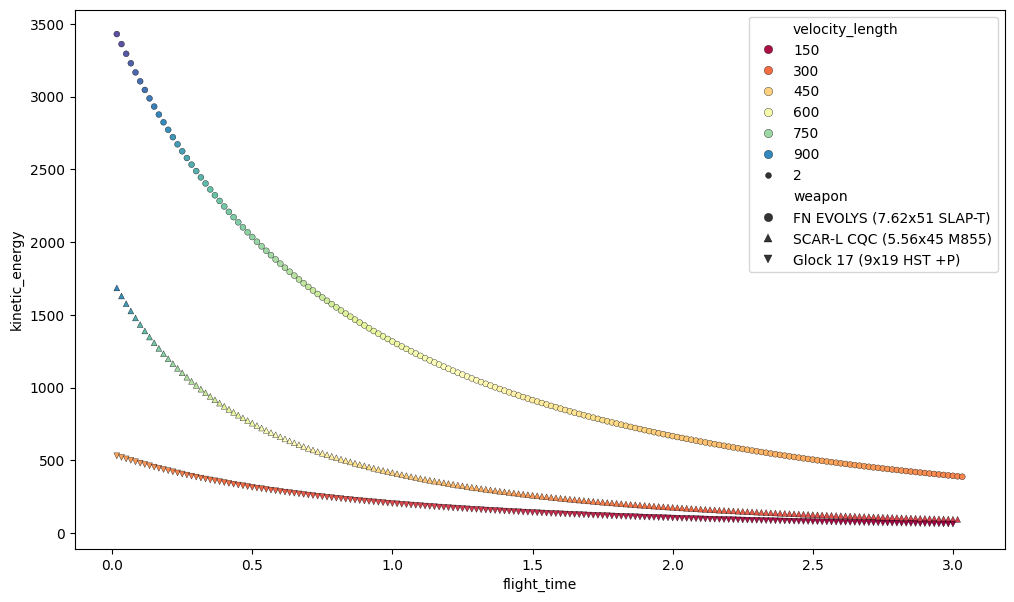

In [50]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 7)
sns.scatterplot(
  ax=ax,
  data=df,
  x='flight_time',
  y='kinetic_energy',
  hue='velocity_length',
  style='weapon',
  markers=['o', '^', 'v'],
  palette='Spectral',
  linewidth=0.25,
  edgecolor='k',
  size=2
)

<Axes: xlabel='flight_time', ylabel='euler.z'>

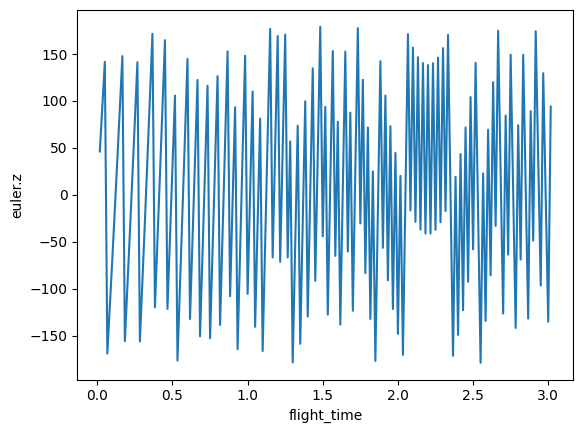

In [51]:
sns.lineplot(
  data=df.query('weapon == "SCAR-L CQC (5.56x45 M855)"'),
  x='flight_time',
  y='euler.z',
  # hue='velocity_length',
  # palette='Spectral',
)

In [55]:
print(df_raw[:1])
df[:1]

                              ammo       ammo.name  angular_velocity  caliber  \
0  <Resource#-9223370991248341223>  7.62x51_SLAP_T      20390.380388     5.56   

   core_caliber  core_hardness  core_mass  cross_section  drag_coef  \
0          5.56           0.85        7.0       0.000024       0.27   

   flight_time  fragmentation_chance  fragmentation_count  fragments_max  \
0     0.016667                   0.5                    0              0   

   fragments_min  impact_count    kind  length  length_diameter_ratio  \
0              0             0  normal    35.0               6.294964   

   magnus_effect_factor  mass  penetration_count  ricochet_count  \
0              0.000315   7.0                  0               0   

   ricochet_max_angle  ricochet_min_angle  \
0                70.0                15.0   

                                            rotation  spin_decay_rate   state  \
0  [X: (0.853748, 0.52067, 0.004101), Y: (-0.5206...            0.998  normal   

   

,uid,flight_time,position.x,position.y,position.z,velocity.x,velocity.y,velocity.z,velocity_length,ang_vel.x,ang_vel.y,ang_vel.z,euler.x,euler.y,euler.z,kinetic_energy,weapon
0,proj_zTFDbjDf,0.016667,0.000001,1.289264,-17.28376,0.000065,7.635225,-989.7986,989.828048,0.0,0.0,-20591.34,-0.451317,-0.000011,-31.378282,3429.158478,FN EVOLYS (7.62x51 SLAP-T)
